# Naive Bayes Training (Google Colab)

Colab-ready notebook for Task 3 sentiment polarity classification using **TF-IDF + Multinomial Naive Bayes**.

This notebook can:
- Train on `corpus_training_hn.csv`, `corpus_training_kaggle.csv`, or both
- Evaluate on `corpus_evaluation.csv`
- Save the trained pipeline, metrics, predictions, and confusion matrix

In [153]:
# # Colab setup
# !pip -q install -U pandas scikit-learn seaborn matplotlib joblib openpyxl

In [154]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import textblob
import spacy

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from textblob import TextBlob

from spacy.matcher import PhraseMatcher
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline

pd.set_option('display.max_columns', None)

In [15]:
# Config
TEXT_COL = 'text_ml'
LABEL_COL = 'sentiment'
LABEL_COL_HN = 'label_sentiment'
LABELS = ['Negative', 'Neutral', 'Positive']

# Where your files live in Colab
BASE_DIR = Path('/Users/brian/Documents/UNI/Y4S2/SC4021/Project')
TRAIN_HN_CSV = BASE_DIR / 'corpus_training_hn.csv'
TRAIN_KAGGLE_CSV = BASE_DIR /  'corpus_kaggle_preprocessed.csv'
EVAL_CSV = BASE_DIR / 'corpus_evaluation.csv'
TEST_CSV = BASE_DIR / 'corpus_no_train_or_eval.csv'
OUTPUT_DIR = BASE_DIR 

# Dataset choice: 'combined', 'hn_only', 'kaggle_only'
TRAIN_MODE = 'combined'

# TF-IDF / NB knobs
LOWERCASE = True
NGRAM_RANGE = (1, 2)
MIN_DF = 2
MAX_DF = 0.95
USE_SUBLINEAR_TF = True
ALPHA = 0.1
# ALPHA = 1


In [ ]:
import spacy
from spacy.matcher import PhraseMatcher


nlp = spacy.load("en_core_web_sm")


models = [
    "xiaomi 14 ultra", "xiaomi 15 ultra", "oneplus 13", "xiaomi 15",
    "pixel 7", "xiaomi 14", "pixel 6", "oneplus 12", "pixel 8",
    "iphone 13", "iphone 13 pro", "iphone 13 pro max",
    "iphone 14", "iphone 14 pro", "iphone 14 pro max",
    "iphone 15", "iphone 15 pro", "iphone 15 pro max",
    "iphone 17", "iphone 17 pro", "iphone 17 pro max",
    "galaxy s21", "galaxy s21 ultra", "galaxy s22", "galaxy s22 ultra",
    "galaxy s23", "galaxy s23 ultra", "galaxy s24", "galaxy s24 ultra",
    "galaxy z fold5", "galaxy z flip5"
]

matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
patterns = [nlp.make_doc(m) for m in models]
matcher.add("PHONE_MODEL", patterns)

def extract_model(text):
    doc = nlp(text) 
    matches = matcher(doc)
    return " ".join([doc[start:end].text for _, start, end in matches])



def extract_entities(text):
    doc = nlp(text)
    return " ".join([ent.label_ for ent in doc.ents])


aspect_keywords = {
    "battery": ["battery", "charge", "charging", "drain", "lasts", "standby"],
    "camera": ["camera", "photo", "video", "lens"],
    "performance": ["fast", "slow", "lag", "smooth", "stutter", "snappy", "warm", "heat", "gaming"],
    "price": ["price", "expensive", "cheap", "cost", "money"],
    "display": ["screen", "display", "bright", "resolution", "gorgeous"]
}

def extract_aspects(text):
    text_lower = text.lower()
    aspects = []

    for aspect, keywords in aspect_keywords.items():
        if any(k in text_lower for k in keywords):
            aspects.append(aspect)

    return " ".join(aspects)  

positive_words = ["good", "great", "amazing", "smooth", "fast", "love", "excellent", "gorgeous"]
negative_words = ["bad", "worse", "lag", "stutter", "issue", "problem", "regret", "average", "okay", "annoying"]

def simple_sentiment(text):
    text = text.lower()

    # phrase rules (important)
    if "not good" in text or "not great" in text:
        return "negative"
    if "not bad" in text:
        return "positive"
    if "just okay" in text or "kind of regret" in text:
        return "negative"

    pos = sum(w in text for w in positive_words)
    neg = sum(w in text for w in negative_words)

    if pos > neg:
        return "positive"
    elif neg > pos:
        return "negative"
    return "neutral"

def split_clauses(text):
    separators = [" but ", " however ", " though ", " although ", ","]
    
    clauses = [text]
    for sep in separators:
        new_clauses = []
        for c in clauses:
            new_clauses.extend(c.split(sep))
        clauses = new_clauses

    return [c.strip() for c in clauses if c.strip()]

def extract_absa(text):
    clauses = split_clauses(text)
    aspect_sentiments = {}

    for clause in clauses:
        aspects = extract_aspects(clause)
        sentiment = simple_sentiment(clause)

        for aspect in aspects:
            if aspect not in aspect_sentiments:
                aspect_sentiments[aspect] = sentiment
            else:
                # prioritize negative if conflicting
                if sentiment == "negative":
                    aspect_sentiments[aspect] = "negative"

    return aspect_sentiments

def extract_sarcasm(text):
    text_lower = text.lower()

    if any(k in text_lower for k in ["yeah right", "sure", "of course"]):
        return "sarcasm"

    if "but" in text_lower and any(n in text_lower for n in [
        "bad", "average", "issue", "problem", "stutter"
    ]):
        return "sarcasm"

    if any(p in text_lower for p in ["expected", "wanted to like", "thought it would"]) \
       and any(n in text_lower for n in ["not", "disappoint", "regret"]):
        return "sarcasm"

    return "nosarcasm"


def analyze_text(text):
    doc = nlp(text)

    return {
        "model": extract_model(doc),
        "entities": extract_entities(doc),
        "aspects": extract_aspects(text),
        "absa": extract_absa(text),
        "sarcasm": extract_sarcasm(text)
    }

In [ ]:
# BEST: USE True, False, True, False
USE_NER = False
USE_ASPECT = True
USE_SARCASM = False
USE_MODEL = False
def build_features(df):
    df = df.copy()
    
    # base text
    df["combined_text"] = df[TEXT_COL]
    
    if USE_MODEL:
        df["model_tag"] = df[TEXT_COL].apply(extract_model)
        df["combined_text"] += " " + df["model_tag"]
    
    if USE_NER:
        df["ner"] = df[TEXT_COL].apply(extract_entities)
        df["combined_text"] += " " + df["ner"]
    
    if USE_ASPECT:
        df["aspect"] = df[TEXT_COL].apply(extract_aspects)
        df["combined_text"] += " " + df["aspect"]
    
    if USE_SARCASM:
        df["sarcasm"] = df[TEXT_COL].apply(extract_sarcasm)
        df["combined_text"] += " " + df["sarcasm"]
    
    return df

In [18]:
cap_map = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}


def load_training_csv(path, text_col, label_col, source_name):
    df = pd.read_csv(path, encoding='utf-8')
    required_cols = {text_col, label_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f'{source_name}: missing columns {missing}. Available: {list(df.columns)}')

    df = df[[text_col, label_col]].dropna().copy()
    df[text_col] = df[text_col].astype(str).str.strip()
    df[label_col] = df[label_col].astype(str).str.strip().replace(cap_map)
    df = df[df[text_col] != ''].copy()

    bad_labels = set(df[label_col].unique()) - set(LABELS)
    if bad_labels:
        raise ValueError(f'{source_name}: unexpected labels {bad_labels}. Expected one of {LABELS}')

    df = df.rename(columns={text_col: TEXT_COL, label_col: LABEL_COL})
    df['source'] = source_name
    return df


def print_label_distribution(name, df):
    print(f'\n{name} size: {len(df)}')
    print(df[LABEL_COL].value_counts().reindex(LABELS, fill_value=0))
    if 'source' in df.columns:
        print('\nSource breakdown:')
        print(df['source'].value_counts())


def load_eval_csv(path):
    df = pd.read_csv(path, encoding='utf-8')
    required_cols = {TEXT_COL, LABEL_COL_HN}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f'Evaluation set missing columns {missing}. Available: {list(df.columns)}')

    df = df[[TEXT_COL, LABEL_COL_HN]].dropna().copy()
    df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
    df[LABEL_COL_HN] = df[LABEL_COL_HN].astype(str).str.strip().replace(cap_map)
    df = df[df[TEXT_COL] != ''].copy()
    df = df.rename(columns={LABEL_COL_HN: LABEL_COL})

    bad_labels = set(df[LABEL_COL].unique()) - set(LABELS)
    if bad_labels:
        raise ValueError(f'Evaluation set has unexpected labels {bad_labels}. Expected one of {LABELS}')

    return df

In [19]:
print(f"NER={USE_NER}, ASPECT={USE_ASPECT}, SARCASM={USE_SARCASM}, MODEL={USE_MODEL}")

NER=False, ASPECT=True, SARCASM=False, MODEL=False


In [7]:
test_df = pd.read_csv(TEST_CSV)
test_df = build_features(test_df)

In [20]:
# Load training data
parts = []

if TRAIN_MODE in {'combined', 'hn_only'}:
    parts.append(load_training_csv(TRAIN_HN_CSV, TEXT_COL, LABEL_COL_HN, 'hackernews'))
if TRAIN_MODE in {'combined', 'kaggle_only'}:
    parts.append(load_training_csv(TRAIN_KAGGLE_CSV, TEXT_COL, LABEL_COL, 'kaggle'))

if not parts:
    raise ValueError("TRAIN_MODE must be one of: 'combined', 'hn_only', 'kaggle_only'")

train_df = pd.concat(parts, ignore_index=True)
train_df = train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
eval_df = load_eval_csv(EVAL_CSV)


print_label_distribution('Training set', train_df)
print_label_distribution('Evaluation set', eval_df)

train_df = build_features(train_df)
eval_df = build_features(eval_df)


train_df.tail()


Training set size: 50899
sentiment
Negative    10157
Neutral     12953
Positive    27789
Name: count, dtype: int64

Source breakdown:
source
kaggle        50000
hackernews      899
Name: count, dtype: int64

Evaluation set size: 1000
sentiment
Negative    352
Neutral     207
Positive    441
Name: count, dtype: int64


,text_ml,sentiment,source,combined_text,aspect
50894,battery life could be slightly good okay for c...,Neutral,kaggle,battery life could be slightly good okay for c...,battery
50895,build quality feel solid and durable absolutel...,Positive,kaggle,build quality feel solid and durable absolutel...,
50896,phone lag often after a few apps very disappoi...,Negative,kaggle,phone lag often after a few apps very disappoi...,performance
50897,do not factory reset your pixel until at least...,Neutral,hackernews,do not factory reset your pixel until at least...,
50898,phone hang often regret buy it not up to the mark,Negative,kaggle,phone hang often regret buy it not up to the m...,


In [11]:
# print(train_df["ner"][50897])

In [21]:
# Build and train TF-IDF + MultinomialNB pipeline
pipeline = Pipeline([
    (
        'tfidf',
        TfidfVectorizer(
            lowercase=LOWERCASE,
            ngram_range=NGRAM_RANGE,
            min_df=MIN_DF,
            max_df=MAX_DF,
            sublinear_tf=USE_SUBLINEAR_TF,
        ),
    ),
    ('nb', MultinomialNB(alpha=ALPHA)),
])



pipeline.fit(train_df["combined_text"], train_df[LABEL_COL])
# pipeline.fit(train_df[TEXT_COL], train_df[LABEL_COL])
print('Training complete.')

Training complete.


Evaluation on corpus_evaluation.csv
NER=False
ASPECT=True 
SARCASM=False 
MODEL=False
N (samples): 1000
Accuracy: 0.8070

Accuracy:   0.8070
Macro F1:   0.8023
Weighted F1:0.8099

Classification report:
              precision    recall  f1-score   support

    Negative     0.7000    0.9148    0.7931       352
     Neutral     0.7558    0.7923    0.7736       207
    Positive     0.9938    0.7279    0.8403       441

    accuracy                         0.8070      1000
   macro avg     0.8165    0.8116    0.8023      1000
weighted avg     0.8411    0.8070    0.8099      1000



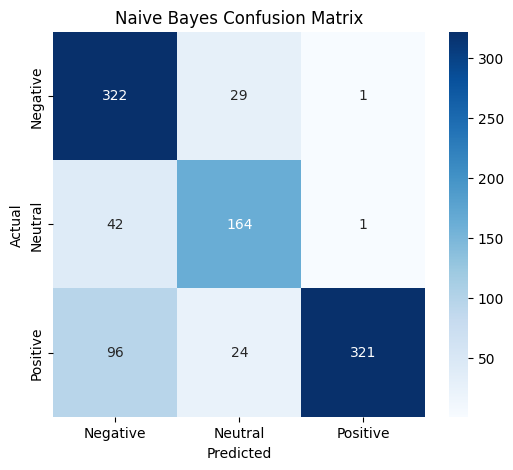

In [22]:
# Evaluate
y_true = eval_df[LABEL_COL]
y_pred = pipeline.predict(eval_df["combined_text"])
probs = pipeline.predict_proba(eval_df["combined_text"])
preds = pipeline.predict(eval_df["combined_text"])


# y_pred = pipeline.predict(eval_df[TEXT_COL])
# y_pred = pipeline.predict(eval_df["combined_text"])
print('=' * 60)
print('Evaluation on corpus_evaluation.csv')
print(f"NER={USE_NER}\nASPECT={USE_ASPECT} \nSARCASM={USE_SARCASM} \nMODEL={USE_MODEL}")
print('=' * 60)
print(f'N (samples): {len(y_true)}')
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print()

# preds = pipeline.predict(eval_df[TEXT_COL])
# probs = pipeline.predict_proba(eval_df[TEXT_COL])


accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')

print(f'Accuracy:   {accuracy:.4f}')
print(f'Macro F1:   {macro_f1:.4f}')
print(f'Weighted F1:{weighted_f1:.4f}')
print('\nClassification report:')
print(classification_report(y_true, y_pred, labels=LABELS, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=LABELS)
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# # Save model and outputs
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# metrics_df = pd.DataFrame([
#     {
#         'train_mode': TRAIN_MODE,
#         'model': 'tfidf_multinomial_nb',
#         'alpha': ALPHA,
#         'ngram_range': str(NGRAM_RANGE),
#         'min_df': MIN_DF,
#         'max_df': MAX_DF,
#         'accuracy': accuracy,
#         'macro_f1': macro_f1,
#         'weighted_f1': weighted_f1,
#         'train_size': len(train_df),
#         'eval_size': len(eval_df),
#         'NER': USE_NER,
#         'ASPECT' : USE_ASPECT,
#         'SARCASM' : USE_SARCASM,
#         'MODEL' : USE_MODEL
#     }
# ])

# predictions_df = eval_df.copy()
# predictions_df['predicted_sentiment'] = y_pred
# for i, label in enumerate(LABELS):
#     predictions_df[f'prob_{label.lower()}'] = probs[:, i]

# joblib.dump(pipeline, OUTPUT_DIR / 'nb_normal_sentiment_alpha=1.joblib')
# # Check if file exists to determine if we need a header
# metrics_path = OUTPUT_DIR / 'metrics.csv'
# file_exists = metrics_path.exists()

# metrics_df.to_csv(
#     metrics_path, 
#     mode='a',              # 'a' stands for append
#     index=False, 
#     header=not file_exists # Only write header if the file is new
# )

# cm_df.to_csv(OUTPUT_DIR / 'confusion_matrix.csv')
# predictions_df.to_csv(OUTPUT_DIR / 'evaluation_predictions.csv', index=False)

# print('Saved to:', OUTPUT_DIR)
# print('- model: nb_pipeline.joblib')
# print('- metrics: metrics.csv')
# print('- confusion matrix: confusion_matrix.csv')
# print('- predictions: evaluation_predictions.csv')
# print(f"NER={USE_NER}\nASPECT={USE_ASPECT} \nSARCASM={USE_SARCASM} \nMODEL={USE_MODEL}")

Saved to: /Users/brian/Downloads/sc4021
- model: nb_pipeline.joblib
- metrics: metrics.csv
- confusion matrix: confusion_matrix.csv
- predictions: evaluation_predictions.csv
NER=False
ASPECT=False 
SARCASM=False 
MODEL=False


In [264]:
# Quick inference test
sample_texts = [
    'The battery life is amazing and the camera is fantastic.',
    'It is okay overall, nothing too special.',
    'Very disappointed with the performance and heating issues.',
]

sample_preds = pipeline.predict(sample_texts)
sample_probs = pipeline.predict_proba(sample_texts)

pd.DataFrame({
    'text': sample_texts,
    'predicted_sentiment': sample_preds,
    'prob_negative': sample_probs[:, 0],
    'prob_neutral': sample_probs[:, 1],
    'prob_positive': sample_probs[:, 2],
})

,text,predicted_sentiment,prob_negative,prob_neutral,prob_positive
0,The battery life is amazing and the camera is ...,Positive,0.338979,0.124655,0.536366
1,"It is okay overall, nothing too special.",Neutral,0.000039,0.999958,0.000003
2,Very disappointed with the performance and hea...,Negative,0.992639,0.005236,0.002126


In [277]:
test_df.head()

,doc_id,object_id,text,text_ml,text_transformer,combined_text,ner,sarcasm
0,2c35da0857258c105dcb57d2e8225713bd04db62,25699626,CO2 already emitted will warm Earth beyond cli...,co2 already emit will warm earth beyond climat...,CO2 already emitted will warm Earth beyond cli...,CO2 already emitted will warm Earth beyond cli...,LOC PRODUCT CARDINAL LOC PRODUCT LOC PRODUCT D...,sarcasm
1,948993f881d25f39700823c0b38cbe4ffe2c27f9,27014953,Will Linux phones stay around this time? > Mic...,will linux phone stay around this time microso...,Will Linux phones stay around this time? Micro...,Will Linux phones stay around this time? Micro...,PERSON ORG ORG ORG PERSON ORG ORG PRODUCT PERS...,nosarcasm
2,24d0f0f1dc4d2a836e6ccea87e69e97d387210b5,27672806,"Bring back menus, QR codes are terrible I thin...",bring back menu qr code be terrible i think yo...,"Bring back menus, QR codes are terrible I thin...","Bring back menus, QR codes are terrible I thin...",PERSON ORG PERSON TIME,nosarcasm
3,cf1c8ce96a65ef7850d26ece36d11fb8868df623,28121859,Apple’s Mistake I dont blame you. After all th...,apple s mistake i dont blame you after all thi...,Apple’s Mistake I dont blame you. After all th...,Apple’s Mistake I dont blame you. After all th...,ORG ORG CARDINAL CARDINAL,nosarcasm
4,cfa4f45f71d0c8cf56db5166ecbe018ac78c0637,28581855,Want to save the earth then don’t buy that shi...,want to save the earth then don t buy that shi...,Want to save the earth then don’t buy that shi...,Want to save the earth then don’t buy that shi...,ORG DATE ORG CARDINAL PERSON CARDINAL ORG ORG ORG,nosarcasm


In [281]:
pred_test = pipeline.predict(test_df["combined_text"])



In [287]:
print(test_df.columns)

Index(['doc_id', 'object_id', 'text', 'text_ml', 'text_transformer',
       'combined_text', 'ner', 'sarcasm'],
      dtype='object')


In [288]:


results_df = test_df[["doc_id", "text_ml"]].copy()
results_df["pred"] = pred_test
results_df.head(20)
results_df.to_csv('results.csv', index=False)